## Step 1: Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import re

# load the data
df = pd.read_csv('data/house_dataset.csv')

# convert dates to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# filter out invalid prices (our target variable) and print them
print("Number of zero or negative prices:", (df['price'] <= 0).sum())
df = df[df['price'] > 0]

# define target as log(price)
df['log_price'] =  np.log(df['price'])

print("Shape after cleaning:", df.shape)
df.tail(1)

Number of zero or negative prices: 98
Shape after cleaning: (9102, 19)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,log_price
9199,2014-07-10,220600.0,3.0,2.5,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA,12.304106


In [2]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country', 'log_price'],
      dtype='object')

## Step 2: EDA, explore the features

In [3]:
# from our raw data columns, we can divide them into numeric and categorical features

numeric_cols = ['price', 'log_price', 'bedrooms','bathrooms','sqft_living','sqft_lot', 'floors','waterfront','view','condition', 'sqft_above','sqft_basement', 'yr_built', 'yr_renovated']
categorical_cols = ['street', 'city', 'statezip','country']

### 1. correlation plots - numeric features against log(price)

- from graph below we can see the top 7 numeric features affecting log(price) are
    - sqft_living
    - sqft_above
    - bathrooms
    - bedrooms
    - floors
    - view
    - waterfront

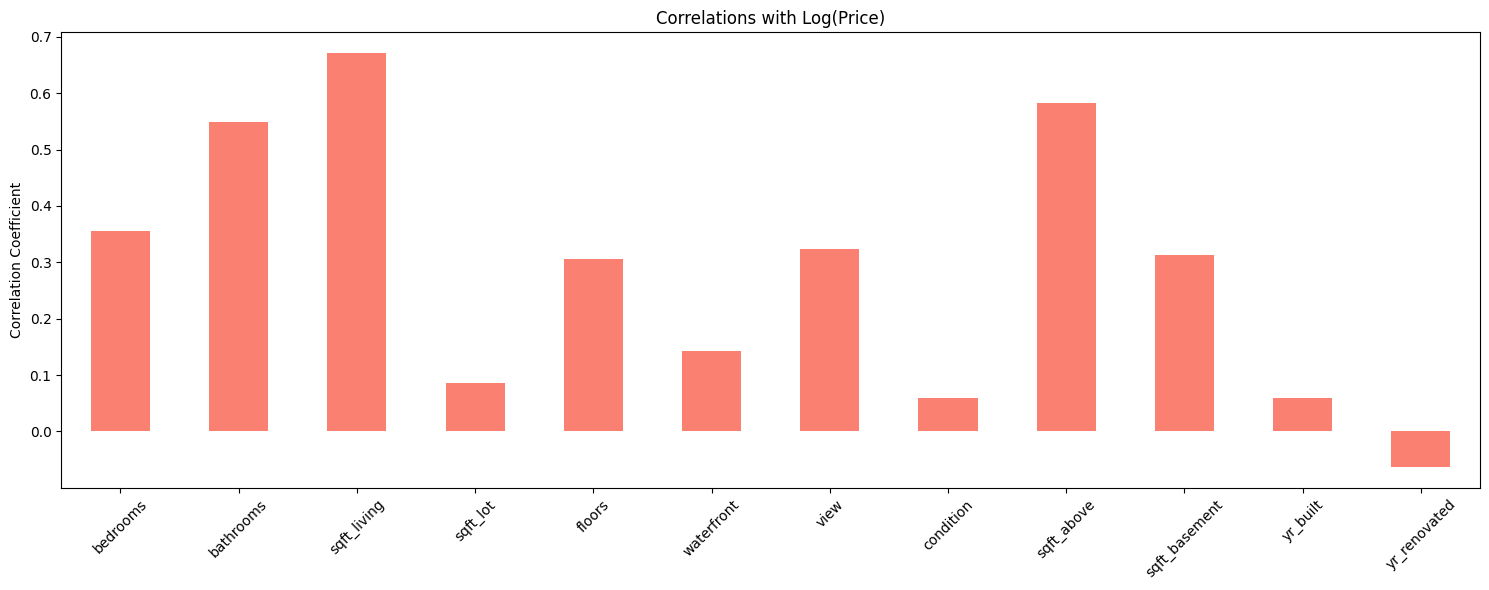

In [4]:
df['log_price'] = np.log(df['price'])

numeric_cols = ['price', 'log_price', 'bedrooms','bathrooms','sqft_living','sqft_lot', 'floors','waterfront','view','condition', 'sqft_above','sqft_basement', 'yr_built', 'yr_renovated']
corr_matrix = df[numeric_cols].corr()
corr_price = corr_matrix['price'].drop(['price','log_price'])
corr_log_price = corr_matrix['log_price'].drop(['price', 'log_price'])  # Correlations of log_price with other features

# Single bar plot for log(price) correlations
plt.figure(figsize=(15, 6))
corr_log_price.plot(kind='bar', color='salmon')
plt.title('Correlations with Log(Price)')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. correlations for categorical features (anova test)

- All the categorical features are statistically significant
- Specificallly
    - Street has the highest F-stat (strongest effect)
    - followed by city, and then statezip
    - country is a unique variable (USA only), so can be dropped
- So we learn that we definitely must include location signals in the model

In [5]:
from scipy.stats import f_oneway

for col in categorical_cols:
    if df[col].nunique() > 1:  # Skip if constant
        groups = [df[df[col] == val]['price'] for val in df[col].unique()]
        f_stat, p_value = f_oneway(*groups)
        print(f"ANOVA for {col} vs. Price: F-stat={f_stat:.2f}, p-value={p_value:.4f}")
        if p_value < 0.05:
            print(f"  Significant association (means differ across {col}).")
        else:
            print(f"  No significant association.")
    else:
        print(f"{col} is constant; skipping ANOVA.")

ANOVA for street vs. Price: F-stat=161.96, p-value=0.0000
  Significant association (means differ across street).
ANOVA for city vs. Price: F-stat=27.13, p-value=0.0000
  Significant association (means differ across city).
ANOVA for statezip vs. Price: F-stat=26.24, p-value=0.0000
  Significant association (means differ across statezip).
country is constant; skipping ANOVA.


## feature engineering based on eda

### 1. numeric feature engineering
- here is the list of numeric features we added to model
    - First, we used top features from EDA correlation plot
    - Next, we added newly created features one by one till MAPE could not be reduced

In [6]:
def get_numeric_feautres():

    numeric_feats = [

        # top 8 from correlation plot, give MAPE = 11.56
        "sqft_living",
        "sqft_above",
        "bathrooms",
        "view",
        "sqft_basement",
        "bedrooms",
        "waterfront",
        "floors", 

        # CREATED features, added one at a time
        "living_lot_ratio", # MAPE -> from 11.56 to 11.42
        "sqft_per_room", # MAPE from 11.42 to 11.11
        "house_age", # MAPE from 11.11 to 11.10
        "view_x_log_sqft", # MAPE from 11.10 to 11.09
        "basement_ratio", # MAPE from 11.09 to 11.06

        

    ]

    ## --------- helpers for the CREATED features are below ------------

    df["living_lot_ratio"] = df["sqft_living"] / (df["sqft_lot"] + 1)
    df["sqft_per_room"] = df["sqft_living"] / (df["bedrooms"] + 1)
    df["sale_year"] = df["date"].dt.year
    df["sale_year"] = df["sale_year"].fillna(df["sale_year"].median())
    df["house_age"] = df["sale_year"] - df["yr_built"]
    df["house_age"] = df["house_age"].clip(0, 150)
    df["log_sqft_living"] = np.log1p(df["sqft_living"])
    df["waterfront_x_log_sqft"] = df["waterfront"] * df["log_sqft_living"] # didnt help
    df["view_x_log_sqft"] = df["view"] * df["log_sqft_living"]
    df["basement_ratio"] = (
            df["sqft_basement"] /
            df["sqft_living"].replace(0, np.nan)
        )
    
    return numeric_feats


### 2. categorical feature engineering

- Added `statezip` and `street_name` as the 2 categorical features
- Removed `country` because only 1
- Removed `city` because through experimentation it reduced MAPE ( probably because contains repeating info with statezip column)
- Preprocessed `street_name` to remove noise by dropping beginning numbers

In [7]:
def get_categorical_features():
    cat_feats = ["statezip", "street_name"] # removed 'city' and 'country'
    

    def extract_street_name(address):
        # Remove leading digits and spaces
        return re.sub(r'^\d+\s*', '', address).strip()
    df['street_name'] = df['street'].apply(extract_street_name)
    return cat_feats

# --------- since street names requires some preprocessing
get_categorical_features()
print("Total unqiue street names:",len(df['street'].unique()))
print('Example of street names:', df['street'].unique()[:3])


print("\nPreprocessed unqiue street names:",len(df['street_name'].unique()))
print('Example of preprocessed street names:', df['street_name'].unique()[:3])

Total unqiue street names: 4476
Example of street names: ['18810 Densmore Ave N' '709 W Blaine St' '26206-26214 143rd Ave SE']

Preprocessed unqiue street names: 2814
Example of preprocessed street names: ['Densmore Ave N' 'W Blaine St' '-26214 143rd Ave SE']


### 3. binary feature engineering

In [8]:
def get_binary_features():
    binary_features = [
    "has_basement", # MAPE from 11.06 to 11.05
    "good_condition", # MAPE from 11.05 to 11.00
    "was_renovated", # made mape worse
        #"high_view", # made mape worse 
    ]

    ## -------------- helpers for binary features -------------------
    df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)
    df["has_basement"] = (df["sqft_basement"] > 0).astype(int)
    df["high_view"] = (df["view"] >= 3).astype(int)
    df["good_condition"] = (df["condition"] >= 4).astype(int)

    return binary_features


## train

| Street-Name Encoding| Numeric Features|	Best MAPE|
|---------|----------|----------|
|One-hot|	17|**11.0%**|
|Frequency|	17|16.7%|
|Target|	17|17.2%|
|None|	17|16.7%|


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

from xgboost import XGBRegressor


# ============================================================
# CONFIG
# ============================================================

street_encoding = "onehot"   
# options: "onehot", "frequency", "target", "none"

# results  onehot:  Best Model: Linear Regression | MAPE = 0.1100 (11.00%)
#                   XGBoost Benchmark: MAPE = 0.1705 (17.05%)
#         frequncy: Best Model: Linear Regression | MAPE = 0.1672 (16.72%)
#                   XGBoost Benchmark: MAPE = 0.1693 (16.93%)
#         target:   Best Model: Linear Regression | MAPE = 0.1718 (17.18%)
#                   XGBoost Benchmark: MAPE = 0.1740 (17.40%)


# ============================================================
# DATA
# ============================================================

numeric_feats, cat_feats, binary_feats = get_numeric_feautres(), get_categorical_features(), get_binary_features()
X = df[numeric_feats + cat_feats + binary_feats].copy()
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()


# ============================================================
# STREET ENCODING OPTIONS
# ============================================================

X_train = X_train.copy()
X_test = X_test.copy()

# make working copies for preprocessing
num_cols = numeric_feats.copy()
cat_cols = cat_feats.copy()
bin_cols = binary_feats.copy()

if street_encoding == "frequency":
    freq = X_train["street_name"].value_counts()

    X_train["street_freq"] = X_train["street_name"].map(freq)
    X_test["street_freq"] = X_test["street_name"].map(freq).fillna(0)

    num_cols.append("street_freq")
    cat_cols = [c for c in cat_cols if c != "street_name"]

    X_train = X_train.drop(columns=["street_name"])
    X_test = X_test.drop(columns=["street_name"])

elif street_encoding == "target":

    train_tmp = X_train.copy()
    train_tmp["log_price"] = y_train

    stats = train_tmp.groupby("street_name")["log_price"].agg(["mean", "count"])

    global_mean = y_train.mean()

    m = 20  # smoothing strength (try 10–50)

    smooth = (stats["mean"] * stats["count"] + global_mean * m) / (stats["count"] + m)

    X_train["street_te"] = X_train["street_name"].map(smooth).fillna(global_mean)
    X_test["street_te"] = X_test["street_name"].map(smooth).fillna(global_mean)

    num_cols.append("street_te")
    cat_cols = [c for c in cat_cols if c != "street_name"]

    X_train = X_train.drop(columns=["street_name"])
    X_test = X_test.drop(columns=["street_name"])
    

elif street_encoding == "onehot":
    if "street_name" not in cat_cols:
        cat_cols.append("street_name")

elif street_encoding == "none":
    cat_cols = [c for c in cat_cols if c != "street_name"]
    X_train = X_train.drop(columns=["street_name"], errors="ignore")
    X_test = X_test.drop(columns=["street_name"], errors="ignore")


# ============================================================
# PREPROCESSOR
# ============================================================


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", SimpleImputer(strategy="most_frequent"), bin_cols),
    ]
)

# ============================================================
# MODELS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=3, max_iter=20000),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# ============================================================
# TRAINING
# ============================================================

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)

    y_pred_log = pipe.predict(X_test)

    y_pred_price = np.exp(y_pred_log)
    y_true_price = np.exp(y_test)

    mse = mean_squared_error(y_true_price, y_pred_price)
    r2 = r2_score(y_true_price, y_pred_price)
    mape = mean_absolute_percentage_error(y_true_price, y_pred_price)

    results.append({
        "Model": name,
       # "MSE": mse,
       # "R2": r2,
        "MAPE": mape
    })


results_df = pd.DataFrame(results).sort_values("MAPE")

print("\nStreet encoding:", street_encoding)
print(results_df)

best = results_df.iloc[0]

# extract XGBoost result if present
xgb_row = results_df[results_df["Model"] == "XGBoost"]

print(
    f"\nBest Model: {best['Model']} | "
    f"MAPE = {best['MAPE']:.4f} ({best['MAPE']*100:.2f}%)"
)

if not xgb_row.empty:
    xgb_mape = xgb_row.iloc[0]["MAPE"]
    print(
        f"XGBoost Benchmark: "
        f"MAPE = {xgb_mape:.4f} ({xgb_mape*100:.2f}%)"
    )


Street encoding: onehot
               Model      MAPE
0  Linear Regression  0.110040
1              Ridge  0.129891
4            XGBoost  0.170487
3        Elastic Net  0.278071
2              Lasso  0.453980

Best Model: Linear Regression | MAPE = 0.1100 (11.00%)
XGBoost Benchmark: MAPE = 0.1705 (17.05%)


## Intepretability of Model

1. Checked `overfitting` of best model ( it is overfitting a bit, so recommendation is to use the frequency encoded model at ~16%)
2. And then `feature intepretability` charts using the coefficients of the features
3. And `accuracy` chart by plotting regression line through the true values

Train vs Test MAPE by Encoding:
Split        Test   Train
Encoding                 
frequency  0.1672  0.1678
none       0.1672  0.1678
onehot     0.1100  0.0647


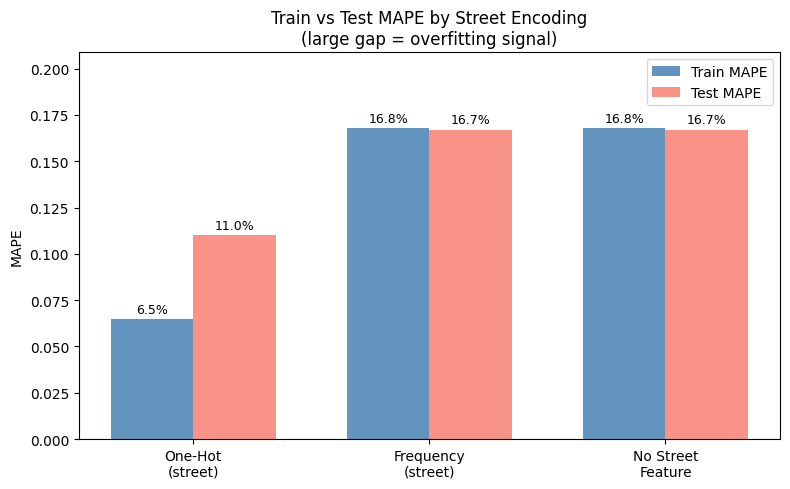


--- Cross-Validation (5-fold) ---
  onehot      : CV MAPE = 0.59% ± 0.03%
  frequency   : CV MAPE = 1.19% ± 0.11%


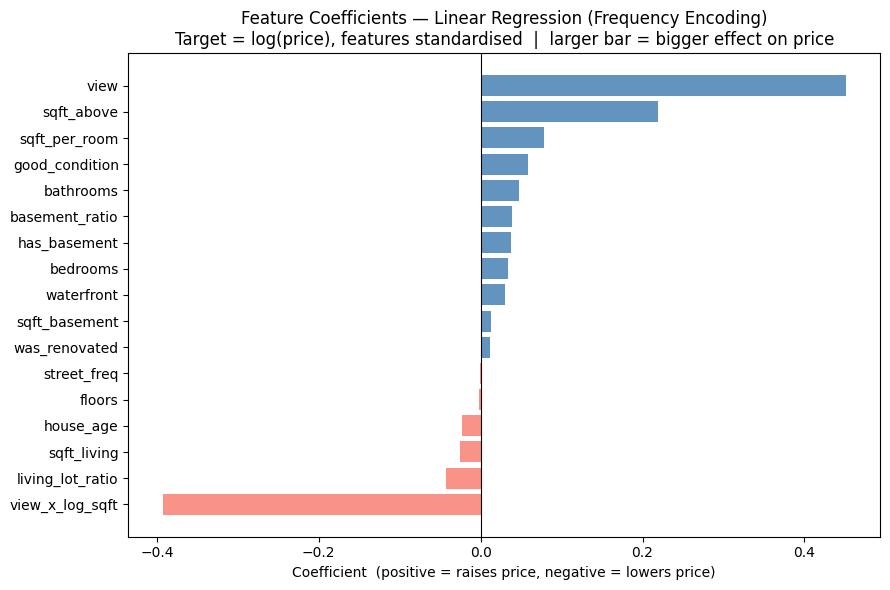

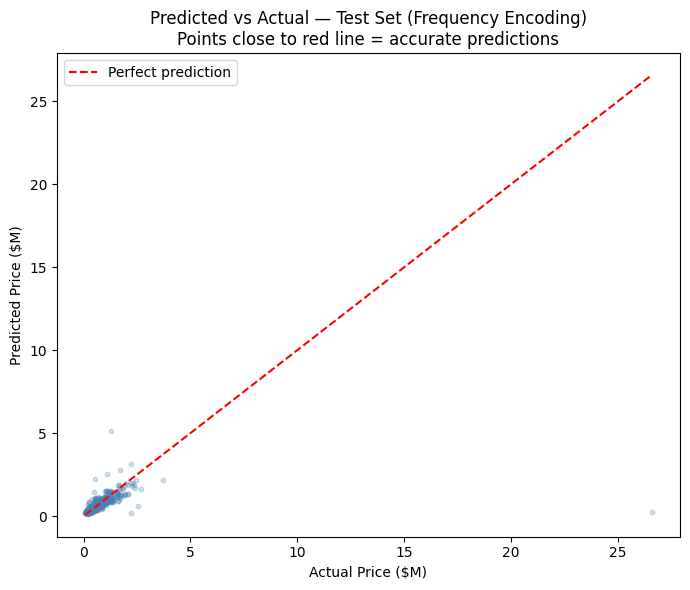

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_percentage_error


# ============================================================
# HELPER: build a pipeline for a given street encoding
# Returns: fitted pipe, X_test, y_test, X_train, y_train
# ============================================================

def build_and_fit(encoding):

    # --- rebuild features fresh each time (functions mutate df) ---
    num_feats = get_numeric_feautres()
    cat_feats = get_categorical_features()
    bin_feats = get_binary_features()

    X = df[num_feats + cat_feats + bin_feats].copy()
    y = df["log_price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    X_train, X_test = X_train.copy(), X_test.copy()

    num_cols = num_feats.copy()
    cat_cols = cat_feats.copy()
    bin_cols = bin_feats.copy()

    # --- apply encoding ---
    if encoding == "frequency":
        freq = X_train["street_name"].value_counts()
        X_train["street_freq"] = X_train["street_name"].map(freq)
        X_test["street_freq"]  = X_test["street_name"].map(freq).fillna(0)
        num_cols.append("street_freq")
        cat_cols = [c for c in cat_cols if c != "street_name"]
        X_train = X_train.drop(columns=["street_name"])
        X_test  = X_test.drop(columns=["street_name"])

    elif encoding == "onehot":
        if "street_name" not in cat_cols:
            cat_cols.append("street_name")

    elif encoding == "none":
        cat_cols = [c for c in cat_cols if c != "street_name"]
        X_train = X_train.drop(columns=["street_name"], errors="ignore")
        X_test  = X_test.drop(columns=["street_name"], errors="ignore")

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(),                        num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"),  cat_cols),
        ("bin", SimpleImputer(strategy="most_frequent"), bin_cols),
    ])

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model",         LinearRegression()),
    ])

    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, y_train, y_test, num_cols, cat_cols, bin_cols


# ============================================================
# 1. OVERFITTING CHECK — Train vs Test MAPE per encoding
# ============================================================

encodings = ["onehot", "frequency", "none"]
ov_results = []

for enc in encodings:
    pipe, X_tr, X_te, y_tr, y_te, _, _, _ = build_and_fit(enc)
    for split_label, X_s, y_s in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        y_pred = np.exp(pipe.predict(X_s))
        y_true = np.exp(y_s)
        mape   = mean_absolute_percentage_error(y_true, y_pred)
        ov_results.append({"Encoding": enc, "Split": split_label, "MAPE": mape})

ov_df = pd.DataFrame(ov_results)
print("Train vs Test MAPE by Encoding:")
print(ov_df.pivot(index="Encoding", columns="Split", values="MAPE").round(4))

# --- bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
enc_labels = encodings
x = np.arange(len(enc_labels))
w = 0.35

train_vals = [ov_df[(ov_df.Encoding==e) & (ov_df.Split=="Train")]["MAPE"].values[0] for e in enc_labels]
test_vals  = [ov_df[(ov_df.Encoding==e) & (ov_df.Split=="Test")]["MAPE"].values[0]  for e in enc_labels]

bars_tr = ax.bar(x - w/2, train_vals, w, label="Train MAPE", color="steelblue",   alpha=0.85)
bars_te = ax.bar(x + w/2, test_vals,  w, label="Test MAPE",  color="salmon",      alpha=0.85)

# annotate values on bars
for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height()*100:.1f}%", ha="center", va="bottom", fontsize=9)
for bar in bars_te:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height()*100:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["One-Hot\n(street)", "Frequency\n(street)", "No Street\nFeature"])
ax.set_ylabel("MAPE")
ax.set_ylim(0, max(test_vals) * 1.25)
ax.set_title("Train vs Test MAPE by Street Encoding\n(large gap = overfitting signal)")
ax.legend()
plt.tight_layout()
plt.show()



# ============================================================
# 2. CROSS-VALIDATION — confirm onehot variance vs frequency
# ============================================================

print("\n--- Cross-Validation (5-fold) ---")

for enc in ["onehot", "frequency"]:
    num_feats = get_numeric_feautres()
    cat_feats = get_categorical_features()
    bin_feats = get_binary_features()

    X = df[num_feats + cat_feats + bin_feats].copy()
    y = df["log_price"]

    num_cols = num_feats.copy()
    cat_cols = cat_feats.copy()
    bin_cols = bin_feats.copy()

    if enc == "frequency":
        # fit freq map on full data (for CV this is a slight leak, but fine for comparison)
        freq = X["street_name"].value_counts()
        X["street_freq"] = X["street_name"].map(freq).fillna(0)
        num_cols.append("street_freq")
        cat_cols = [c for c in cat_cols if c != "street_name"]
        X = X.drop(columns=["street_name"])
    elif enc == "onehot":
        if "street_name" not in cat_cols:
            cat_cols.append("street_name")

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(),                        num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"),  cat_cols),
        ("bin", SimpleImputer(strategy="most_frequent"), bin_cols),
    ])
    pipe = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])

    scores = cross_val_score(pipe, X, y, cv=5,
                             scoring="neg_mean_absolute_percentage_error")
    mapes  = -scores
    print(f"  {enc:12s}: CV MAPE = {mapes.mean()*100:.2f}% ± {mapes.std()*100:.2f}%")


# ============================================================
# 3. FEATURE COEFFICIENTS — best generalising model (frequency)
# ============================================================

pipe, X_tr, X_te, y_tr, y_te, num_cols, cat_cols, bin_cols = build_and_fit("frequency")

lr_model    = pipe.named_steps["model"]
preproc     = pipe.named_steps["preprocessor"]
cat_names   = preproc.named_transformers_["cat"] \
                      .get_feature_names_out(cat_cols).tolist()
all_names   = num_cols + cat_names + bin_cols

coef_df = pd.DataFrame({"Feature": all_names, "Coefficient": lr_model.coef_})

# keep only numeric + binary (readable; skip hundreds of OHE dummies)
plot_df = coef_df[coef_df["Feature"].isin(num_cols + bin_cols)].copy()
plot_df = plot_df.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["salmon" if c < 0 else "steelblue" for c in plot_df["Coefficient"]]
ax.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Coefficients — Linear Regression (Frequency Encoding)\n"
             "Target = log(price), features standardised  |  larger bar = bigger effect on price")
ax.set_xlabel("Coefficient  (positive = raises price, negative = lowers price)")
plt.tight_layout()
plt.show()


# ============================================================
# 4. PREDICTED vs ACTUAL — sanity check scatter
# ============================================================

y_pred_price = np.exp(pipe.predict(X_te))
y_true_price = np.exp(y_te)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true_price / 1e6, y_pred_price / 1e6,
           alpha=0.25, s=10, color="steelblue")

lim_min = min(y_true_price.min(), y_pred_price.min()) / 1e6
lim_max = max(y_true_price.max(), y_pred_price.max()) / 1e6
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        "r--", linewidth=1.5, label="Perfect prediction")

ax.set_xlabel("Actual Price ($M)")
ax.set_ylabel("Predicted Price ($M)")
ax.set_title("Predicted vs Actual — Test Set (Frequency Encoding)\n"
             "Points close to red line = accurate predictions")
ax.legend()
plt.tight_layout()

plt.show()
